# 04 — Modelo de severidade

Prever se um caso terá **desfecho sério** (DE, LT, HO, DS, CA, RI) dado o paciente e a droga reportada. Útil para priorizar revisão manual de casos.

**Importante:** o target é balanceado (~49% sério) — diferente do projeto 1.

## Roteiro
1. Construir features no nível do caso (1 linha = 1 caso)
2. Split treino/val/teste
3. Baseline logística
4. XGBoost + Optuna
5. SHAP
6. Salvar modelo final

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report
)
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import optuna
import shap

from src.preprocess import (
    dedupe_demo, normalize_age, normalize_drug_table, aggregate_outcomes
)
from src.features import build_case_features, NUMERIC_COLS, CATEGORICAL_COLS

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

PROCESSED = Path.cwd().parent / "data" / "processed"
MODELS_DIR = Path.cwd().parent / "models"
FIG_DIR = Path.cwd().parent / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carregar e preparar dados

In [2]:
demo = normalize_age(dedupe_demo(pd.read_parquet(PROCESSED / "demo_2023.parquet")))
drug = normalize_drug_table(pd.read_parquet(PROCESSED / "drug_2023.parquet"))
indi = pd.read_parquet(PROCESSED / "indi_2023.parquet")
rpsr = pd.read_parquet(PROCESSED / "rpsr_2023.parquet")
outc_agg = aggregate_outcomes(pd.read_parquet(PROCESSED / "outc_2023.parquet"))

feats = build_case_features(demo, drug, indi, outc_agg, rpsr)
print(f"Casos com features: {len(feats):,}")
print(f"Taxa do target (serious): {feats['target'].mean()*100:.1f}%")
feats.head(3)

Casos com features: 961,967
Taxa do target (serious): 49.3%


,caseid,age_years,sex,n_drugs_total,n_drugs_ps,n_drugs_concomitant,primary_drug,n_indications,primary_indication,reporter_type,target
0,10011639,44.000000,F,7.0,1.0,0.0,OTHER,2.0,OTHER,UNK,0
1,10014432,64.000000,F,100.0,1.0,0.0,OTHER,46.0,PRODUCT USED FOR UNKNOWN INDICATION,UNK,1
2,10014483,0.153846,UNK,43.0,1.0,15.0,OTHER,28.0,HIV INFECTION,UNK,0


In [3]:
feats[NUMERIC_COLS].describe().round(2)

,age_years,n_drugs_total,n_drugs_ps,n_drugs_concomitant,n_indications
count,597102.00,961967.00,961967.00,961967.00,961967.00
mean,56.06,8.45,1.20,3.19,4.65
std,20.96,33.08,0.49,11.64,15.61
min,0.00,0.00,0.00,0.00,0.00
25%,43.00,1.00,1.00,0.00,1.00
50%,60.00,3.00,1.00,0.00,2.00
75%,72.00,7.00,1.00,2.00,4.00
max,110.00,2986.00,4.00,1531.00,2981.00


## 2. Split

In [4]:
X = feats[NUMERIC_COLS + CATEGORICAL_COLS]
y = feats["target"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176, stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,} ({y_train.mean()*100:.1f}% pos)")
print(f"Val:   {len(X_val):,} ({y_val.mean()*100:.1f}% pos)")
print(f"Test:  {len(X_test):,} ({y_test.mean()*100:.1f}% pos)")

Train: 673,760 (49.3% pos)
Val:   143,911 (49.3% pos)
Test:  144,296 (49.3% pos)


## 3. Pré-processamento

In [5]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="UNK")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)),
])

preprocessor_lin = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC_COLS),
    ("cat", categorical_pipe, CATEGORICAL_COLS),
])
preprocessor_tree = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), NUMERIC_COLS),
    ("cat", categorical_pipe, CATEGORICAL_COLS),
])

X_train_lin = preprocessor_lin.fit_transform(X_train)
X_val_lin   = preprocessor_lin.transform(X_val)
X_test_lin  = preprocessor_lin.transform(X_test)

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_val_tree   = preprocessor_tree.transform(X_val)
X_test_tree  = preprocessor_tree.transform(X_test)

feature_names = preprocessor_tree.get_feature_names_out()
print(f"Features após one-hot: {X_train_tree.shape[1]}")

Features após one-hot: 315


## 4. Baseline: Logistic Regression

In [6]:
logreg = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE, n_jobs=-1)
logreg.fit(X_train_lin, y_train)
score_logreg = logreg.predict_proba(X_test_lin)[:, 1]

results = []
def add_result(name, score):
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, score),
        "pr_auc": average_precision_score(y_test, score),
        "brier": brier_score_loss(y_test, score),
    })

add_result("Logistic Regression", score_logreg)
results[-1]

{'model': 'Logistic Regression',
 'roc_auc': 0.6962100865480398,
 'pr_auc': 0.6741202459769112,
 'brier': 0.2190037136986712}

## 5. XGBoost — default

In [7]:
xgb_default = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    eval_metric="logloss", early_stopping_rounds=30,
    tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_default.fit(X_train_tree, y_train, eval_set=[(X_val_tree, y_val)], verbose=False)
print(f"Best iteration: {xgb_default.best_iteration}")

score_xgb_def = xgb_default.predict_proba(X_test_tree)[:, 1]
add_result("XGBoost (default)", score_xgb_def)
results[-1]

Best iteration: 499


{'model': 'XGBoost (default)',
 'roc_auc': 0.7164220268013,
 'pr_auc': 0.703005866859649,
 'brier': 0.2133786827325821}

## 6. XGBoost — tunado com Optuna

In [8]:
def objective(trial):
    params = {
        "n_estimators": 600,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "eval_metric": "logloss",
        "early_stopping_rounds": 20,
        "tree_method": "hist",
        "random_state": RANDOM_STATE, "n_jobs": -1,
    }
    m = XGBClassifier(**params)
    m.fit(X_train_tree, y_train, eval_set=[(X_val_tree, y_val)], verbose=False)
    pred = m.predict_proba(X_val_tree)[:, 1]
    return roc_auc_score(y_val, pred)

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=25, show_progress_bar=False)

print(f"Best ROC-AUC (val): {study.best_value:.4f}")
print(study.best_params)

Best ROC-AUC (val): 0.7376
{'learning_rate': 0.1438045461582311, 'max_depth': 8, 'min_child_weight': 4, 'subsample': 0.7478592694920541, 'colsample_bytree': 0.8481768129192566, 'gamma': 1.51723150444279, 'reg_alpha': 0.004123738858862993, 'reg_lambda': 0.24496827822873485}


In [9]:
best = study.best_params | {
    "n_estimators": 800, "eval_metric": "logloss",
    "early_stopping_rounds": 30, "tree_method": "hist",
    "random_state": RANDOM_STATE, "n_jobs": -1,
}
xgb_tuned = XGBClassifier(**best)
xgb_tuned.fit(X_train_tree, y_train, eval_set=[(X_val_tree, y_val)], verbose=False)

score_xgb = xgb_tuned.predict_proba(X_test_tree)[:, 1]
add_result("XGBoost (Optuna)", score_xgb)
pd.DataFrame(results).set_index("model").round(4)

,roc_auc,pr_auc,brier
model,,,
Logistic Regression,0.6962,0.6741,0.2190
XGBoost (default),0.7164,0.7030,0.2134
XGBoost (Optuna),0.7445,0.7338,0.2038


## 7. SHAP — o que dirige a severidade?

In [10]:
explainer = shap.TreeExplainer(xgb_tuned)
sample_idx = np.random.default_rng(42).choice(len(X_test_tree), size=3000, replace=False)
X_sample = X_test_tree[sample_idx]
shap_values = explainer.shap_values(X_sample)

importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
importance.head(20)

,feature,mean_abs_shap
0,num__age_years,0.237019
4,num__n_indications,0.088415
1,num__n_drugs_total,0.083536
6,cat__sex_M,0.081877
3,num__n_drugs_concomitant,0.081067
2,num__n_drugs_ps,0.052187
13,cat__primary_drug_ACETAMINOPHEN HYDROCODONE BI...,0.049752
314,cat__reporter_type_UNK,0.047719
149,cat__primary_drug_OTHER,0.041786
14,cat__primary_drug_ACETAMINOPHEN OXYCODONE,0.039201


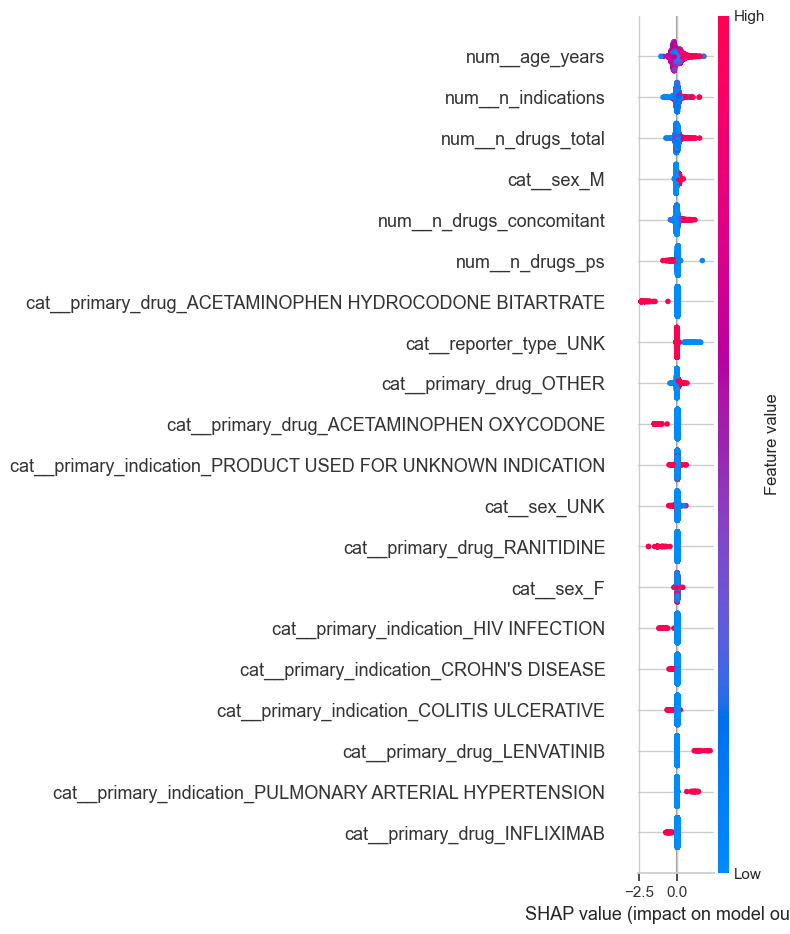

In [11]:
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=list(feature_names), max_display=20, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_shap_severity.png", bbox_inches="tight")
plt.show()

## 8. Salvar tudo

In [12]:
joblib.dump(xgb_tuned, MODELS_DIR / "xgb_severity.pkl")
joblib.dump(preprocessor_tree, MODELS_DIR / "preprocessor_severity.pkl")
joblib.dump(logreg, MODELS_DIR / "logreg_severity.pkl")
joblib.dump(preprocessor_lin, MODELS_DIR / "preprocessor_severity_lin.pkl")

metrics_df = pd.DataFrame(results).set_index("model").round(4)
metrics_df.to_csv(Path.cwd().parent / "reports" / "severity_metrics.csv")
print(metrics_df)
print("\n✓ Modelos e métricas salvos.")

                     roc_auc  pr_auc   brier
model                                       
Logistic Regression   0.6962  0.6741  0.2190
XGBoost (default)     0.7164  0.7030  0.2134
XGBoost (Optuna)      0.7445  0.7338  0.2038

✓ Modelos e métricas salvos.
